# Ideology Embeddings — probing Dutch parliamentary speech with RobBERT

Find **ideology direction vectors** in Dutch BERT's embedding space, using Tweede Kamer speeches as labelled training data.

| Phase | What we do |
|-------|------------|
| **1A** | Fetch speeches from `gegevensmagazijn.tweedekamer.nl` |
| **1B** | Embed with Dutch RobBERT (mean-pooled hidden states) |
| **1C** | UMAP visualization — do parties cluster geometrically? |
| **2A** | Compute `mean(A) − mean(B)` direction vectors |
| **2B** | Find vocabulary that loads most on each direction |
| **3**  | Project unseen text onto the axes → continuous ideology score |

**Key idea:** If BERT-space separates parties meaningfully, then a direction vector
captures something like "political essence", and we can score any text on it.

## Setup

In [1]:
# Install dependencies (or use the provided requirements.txt):
#   pip install -r requirements.txt


In [2]:
import os, re, time, html as html_lib
from collections import defaultdict, Counter

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm.notebook import tqdm

from sklearn.decomposition import PCA
import umap

import torch
from transformers import AutoTokenizer, AutoModel

# ── Configuration — edit these ────────────────────────────────────────────────
BASE_URL = "https://gegevensmagazijn.tweedekamer.nl/OData/v4/2.0/"

MODEL_NAME          = "DTAI-KULeuven/robbert-2023-dutch-base"
SPEECHES_PER_PARTY  = 80
MIN_CHARS           = 300
MAX_CHARS           = 4000
EMBED_BATCH_SIZE    = 16   # can go higher on GPU/MPS
DATA_FILE           = "speeches.csv"
EMBED_FILE          = "embeddings.npy"

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print(f"Device: {DEVICE}")

Device: mps


---
## Phase 1A — Fetch Data from Tweede Kamer API

Navigation path: **`Fractie`** (parties) → **`FractieZetel`** (person↔party membership) → **`Spreekbeurt`** (speeches).

Run the sanity-check cell first — it shows you the real field names before anything breaks.

In [3]:
# Sanity check: verify the API is reachable and inspect the Verslag XML format
import requests, re, html as html_lib
from collections import defaultdict, Counter

BASE_URL = "https://gegevensmagazijn.tweedekamer.nl/OData/v4/2.0/"

# Fetch one recent plenary vergadering to confirm access
r = requests.get(BASE_URL + "Vergadering",
                 params={"$filter": "Soort eq 'Plenair'", "$top": "1", "$orderby": "Datum desc",
                         "$expand": "Verslag"})
r.raise_for_status()
v = r.json()["value"][0]
print(f"Latest plenary session: {v['Datum'][:10]}  —  {v['Titel']}")
print(f"Number of Verslagen: {len(v['Verslag'])}")

# Download one Verslag XML and show its structure
vid = v["Verslag"][-1]["Id"]   # take the largest/latest
rx = requests.get(f"{BASE_URL}Verslag({vid})/resource")
print(f"\nVerslag XML size: {len(rx.text):,} chars")
print("First 400 chars of XML:")
print(rx.text.lstrip("﻿")[:400])

Latest plenary session: 2026-05-21  —  72e vergadering, donderdag 21 mei 2026
Number of Verslagen: 9

Verslag XML size: 1,041,435 chars
First 400 chars of XML:
ï»¿<?xml version="1.0" encoding="UTF-8" standalone="no"?><vlosCoreDocument MessageID="0a70fc69-0cdf-4b96-ad69-7f3b5a0d7e08" Source="VLOS2.0" MessageType="vlos2document" Timestamp="2026-05-21T20:27:39.9845363+02:00" soort="Tussenpublicatie" status="Ongecorrigeerd" technischeaanpassing="false" publiceren="Ja" versie="1.3" xmlns="http://www.tweedekamer.nl/ggm/vergaderverslag/v1.0"><vergadering soort=


In [4]:
def parse_verslag_xml(xml_text, min_chars=MIN_CHARS, max_chars=MAX_CHARS):
    """
    Extract (party, text) tuples from a VLOS Verslag XML.
    
    Structure: <activiteitdeel soort="Spreekbeurt"> contains
      <fractie>PVV</fractie>  ← party, embedded directly in XML
      <alineaitem>...</alineaitem>  ← speech text paragraphs
      <isvoorzitter>true</isvoorzitter>  ← skip chair procedurals
    """
    xml_text = xml_text.lstrip("﻿")
    speeches = []

    # Split on speech turns
    blocks = re.split(r'<activiteitdeel soort="Spreekbeurt"', xml_text)[1:]

    for block in blocks:
        end = block.find("</activiteitdeel>")
        if end >= 0:
            block = block[:end]

        # Skip chair speeches (procedural)
        if "<isvoorzitter>true</isvoorzitter>" in block:
            continue

        fractie_m = re.search(r"<fractie>(.*?)</fractie>", block)
        if not fractie_m:
            continue
        party = fractie_m.group(1).strip()

        # Collect all paragraph text
        items = re.findall(r"<alineaitem>(.*?)</alineaitem>", block, re.DOTALL)
        if not items:
            continue

        text = " ".join(items)
        text = re.sub(r"<[^>]+>", "", text)     # strip inner XML tags
        text = html_lib.unescape(text)
        text = re.sub(r"\s+", " ", text).strip()

        if min_chars <= len(text) <= max_chars:
            speeches.append((party, text))

    return speeches


# Quick test
r_test = requests.get(BASE_URL + "Vergadering",
                      params={"$filter": "Soort eq 'Plenair'", "$top": "1",
                               "$orderby": "Datum desc", "$expand": "Verslag"})
test_vergadering = r_test.json()["value"][0]
vid_test = max(test_vergadering["Verslag"], key=lambda v: v["ContentLength"])["Id"]
xml_test = requests.get(f"{BASE_URL}Verslag({vid_test})/resource").text
speeches_test = parse_verslag_xml(xml_test)

print(f"Parser test on {test_vergadering['Datum'][:10]}:")
print(f"  {len(speeches_test)} speeches extracted")
print("  Party counts:", dict(Counter(p for p, _ in speeches_test).most_common(8)))

Parser test on 2026-05-21:
  7 speeches extracted
  Party counts: {'GroenLinks-PvdA': 1, 'Lid Keijzer': 1, 'D66': 1, 'FVD': 1, 'BBB': 1, 'PvdD': 1, 'JA21': 1}


In [5]:
import time, os
import pandas as pd

def fetch_vergadering_ids(n_sessions=30):
    """Return IDs of the n most recent plenary session Verslagen (largest XML per session)."""
    r = requests.get(BASE_URL + "Vergadering",
                     params={"$filter": "Soort eq 'Plenair'",
                             "$top": str(n_sessions),
                             "$orderby": "Datum desc",
                             "$expand": "Verslag"})
    r.raise_for_status()
    verslag_ids = []
    for vergadering in r.json()["value"]:
        verslagen = [v for v in vergadering.get("Verslag", []) if v["ContentLength"] > 50_000]
        if verslagen:
            # Take the largest Verslag per session (most complete transcript)
            best = max(verslagen, key=lambda v: v["ContentLength"])
            verslag_ids.append((vergadering["Datum"][:10], best["Id"]))
    return verslag_ids

# ── Main fetch + parse (or load checkpoint) ──────────────────────────────────
if os.path.exists(DATA_FILE):
    speeches_df = pd.read_csv(DATA_FILE)
    print(f"Loaded {len(speeches_df)} speeches from {DATA_FILE!r} (delete to re-fetch)")
else:
    verslag_ids = fetch_vergadering_ids(n_sessions=40)
    print(f"Found {len(verslag_ids)} plenary sessions to fetch")

    all_records = []
    for date, vid in verslag_ids:
        try:
            rx = requests.get(f"{BASE_URL}Verslag({vid})/resource", timeout=30)
            rx.raise_for_status()
            parsed = parse_verslag_xml(rx.text)
            for party, text in parsed:
                all_records.append({"party": party, "text": text})
            print(f"  {date}: {len(parsed):3d} speeches  (total so far: {len(all_records)})")
        except Exception as e:
            print(f"  {date}: error — {e}")
        time.sleep(0.3)

    speeches_df = pd.DataFrame(all_records)
    speeches_df.to_csv(DATA_FILE, index=False)
    print(f"\nSaved {len(speeches_df)} speeches to {DATA_FILE!r}")

print("\nSpeeches per party (top 15):")
print(speeches_df["party"].value_counts().head(15))

Loaded 563 speeches from 'speeches.csv' (delete to re-fetch)

Speeches per party (top 15):
party
GroenLinks-PvdA      93
BBB                  63
Groep Markuszower    61
PVV                  48
DENK                 47
SP                   45
JA21                 38
ChristenUnie         34
VVD                  27
Lid Keijzer          21
PvdD                 19
D66                  18
Volt                 14
CDA                  14
FVD                  13
Name: count, dtype: int64


In [6]:
# Filter to the parties we want to compare, sampling evenly
# Party names in the XML use full names — adjust PARTIES in the config cell to match
# what appeared in the output above (e.g. "GroenLinks-PvdA", not "GL-PvdA")
PARTIES = ["PVV", "VVD", "D66", "GroenLinks-PvdA", "NSC", "CDA", "SP"]

in_data = set(speeches_df["party"].unique())
missing = [p for p in PARTIES if p not in in_data]
if missing:
    print(f"⚠️  Not found in data: {missing}")
    print("   Available parties:", sorted(in_data))
    print("   Update PARTIES above to match.")
else:
    print("✓  All target parties present in data")

# Sample up to SPEECHES_PER_PARTY per party for balanced training
sampled = (
    speeches_df[speeches_df["party"].isin(PARTIES)]
    .groupby("party", group_keys=False)
    .apply(lambda g: g.sample(min(len(g), SPEECHES_PER_PARTY), random_state=42))
    .reset_index(drop=True)
)
speeches_df = sampled
print(f"\nAfter sampling — {len(speeches_df)} speeches:")
print(speeches_df["party"].value_counts())

⚠️  Not found in data: ['NSC']
   Available parties: ['50PLUS', 'BBB', 'CDA', 'ChristenUnie', 'D66', 'DENK', 'FVD', 'GroenLinks-PvdA', 'Groep Markuszower', 'JA21', 'Lid Keijzer', 'PVV', 'PvdD', 'SGP', 'SP', 'VVD', 'Volt']
   Update PARTIES above to match.

After sampling — 232 speeches:
party
GroenLinks-PvdA    80
PVV                48
SP                 45
VVD                27
D66                18
CDA                14
Name: count, dtype: int64


<tmp> FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  speeches_df[speeches_df["party"].isin(PARTIES)]


---
## Phase 1B — Embed Speeches with Dutch RobBERT

**What we extract:** the mean of all non-padding token vectors from the last hidden layer.
This gives a 768-dimensional sentence embedding per speech.

Long speeches are silently truncated to 512 tokens (~350 Dutch words).  
Embeddings are cached to disk — re-running this cell is instant after the first time.

In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()
n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Loaded {MODEL_NAME}  ({n_params:.0f}M parameters)")

Some weights of RobertaModel were not initialized from the model checkpoint at DTAI-KULeuven/robbert-2023-dutch-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded DTAI-KULeuven/robbert-2023-dutch-base  (124M parameters)


In [8]:
def mean_pool(last_hidden_state, attention_mask):
    """Average token embeddings, ignoring padding tokens."""
    mask = attention_mask.unsqueeze(-1).float()  # (B, L, 1)
    summed = (last_hidden_state * mask).sum(dim=1)  # (B, H)
    n_tokens = mask.sum(dim=1).clamp(min=1e-9)       # (B, 1)
    return summed / n_tokens                           # (B, H)

@torch.no_grad()
def embed_texts(texts, batch_size=EMBED_BATCH_SIZE):
    vecs = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Embedding"):
        batch = texts[i : i + batch_size]
        enc = tokenizer(
            batch, padding=True, truncation=True,
            max_length=512, return_tensors="pt"
        ).to(DEVICE)
        out = model(**enc)
        v = mean_pool(out.last_hidden_state, enc.attention_mask)
        vecs.append(v.cpu().numpy())
    return np.vstack(vecs)


if os.path.exists(EMBED_FILE):
    embeddings = np.load(EMBED_FILE)
    print(f"Loaded embeddings from {EMBED_FILE!r}: shape {embeddings.shape}")
    assert len(embeddings) == len(speeches_df), "Mismatch — delete embeddings.npy and re-run"
else:
    embeddings = embed_texts(speeches_df["text"].tolist())
    np.save(EMBED_FILE, embeddings)
    print(f"Saved embeddings: {embeddings.shape}  →  {EMBED_FILE!r}")

Loaded embeddings from 'embeddings.npy': shape (232, 768)


---
## Phase 1C — Visualize Party Clusters

PCA to 50 dimensions first (denoises, speeds up UMAP), then UMAP to 2D.

**What to look for:**
- Do left and right wing parties separate?
- Are similar parties (e.g. VVD & NSC) near each other?
- Is PVV isolated, or does it overlap with other right-wing parties?

PCA (50 components) explains 77.4% of variance


<path> UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
<tmp> MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(parties_present))


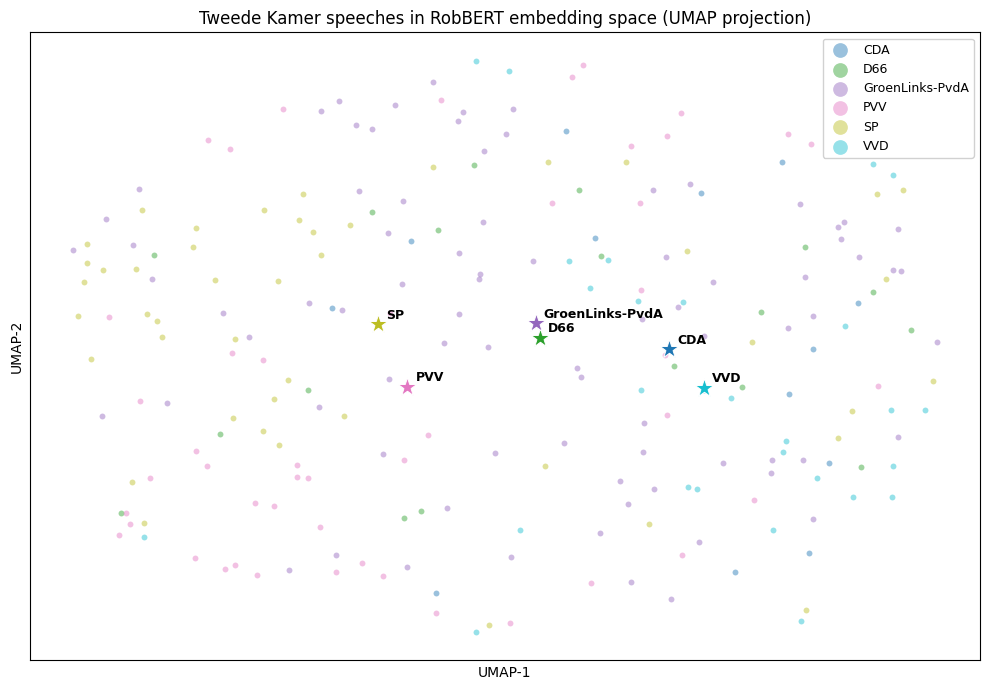

Saved: party_clusters.png


In [9]:
# PCA → UMAP
pca = PCA(n_components=50, random_state=42)
emb_pca = pca.fit_transform(embeddings)
var_explained = pca.explained_variance_ratio_.sum()
print(f"PCA (50 components) explains {var_explained:.1%} of variance")

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42, verbose=False)
emb_2d = reducer.fit_transform(emb_pca)

# Plot
parties_present = sorted(speeches_df["party"].unique())
colors = cm.get_cmap("tab10", len(parties_present))
party_color = {p: colors(i) for i, p in enumerate(parties_present)}

fig, ax = plt.subplots(figsize=(10, 7))
for party, group in speeches_df.groupby("party"):
    idx = group.index
    ax.scatter(
        emb_2d[idx, 0], emb_2d[idx, 1],
        c=[party_color[party]], label=party,
        alpha=0.45, s=18, linewidths=0,
    )

# Add party centroids as larger markers
for party, group in speeches_df.groupby("party"):
    idx = group.index
    cx, cy = emb_2d[idx, 0].mean(), emb_2d[idx, 1].mean()
    ax.scatter(cx, cy, c=[party_color[party]], s=200, marker="*",
               edgecolors="white", linewidths=0.7, zorder=5)
    ax.annotate(party, (cx, cy), textcoords="offset points",
                xytext=(6, 4), fontsize=9, fontweight="bold")

ax.legend(markerscale=2.5, framealpha=0.9, fontsize=9)
ax.set_title("Tweede Kamer speeches in RobBERT embedding space (UMAP projection)", fontsize=12)
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig("party_clusters.png", dpi=150)
plt.show()
print("Saved: party_clusters.png")

---
## Phase 2A — Party Direction Vectors

Each party has a **centroid** — the mean of all its speech embeddings in BERT's 768-dimensional space.

The **direction vector** from party B to party A is:

$$\hat{d}_{A \leftrightarrow B} = \frac{\mu_A - \mu_B}{\|\mu_A - \mu_B\|}$$

This is a unit vector (length 1) pointing through BERT space from "sounds like B" toward "sounds like A".  
Projecting any embedding onto it collapses 768 dimensions down to a single scalar: how far along that political axis the text sits.

This is the "party vector" — a direction in a space where meaning is geometry.

Party centroids computed for: ['CDA', 'D66', 'GroenLinks-PvdA', 'PVV', 'SP', 'VVD']


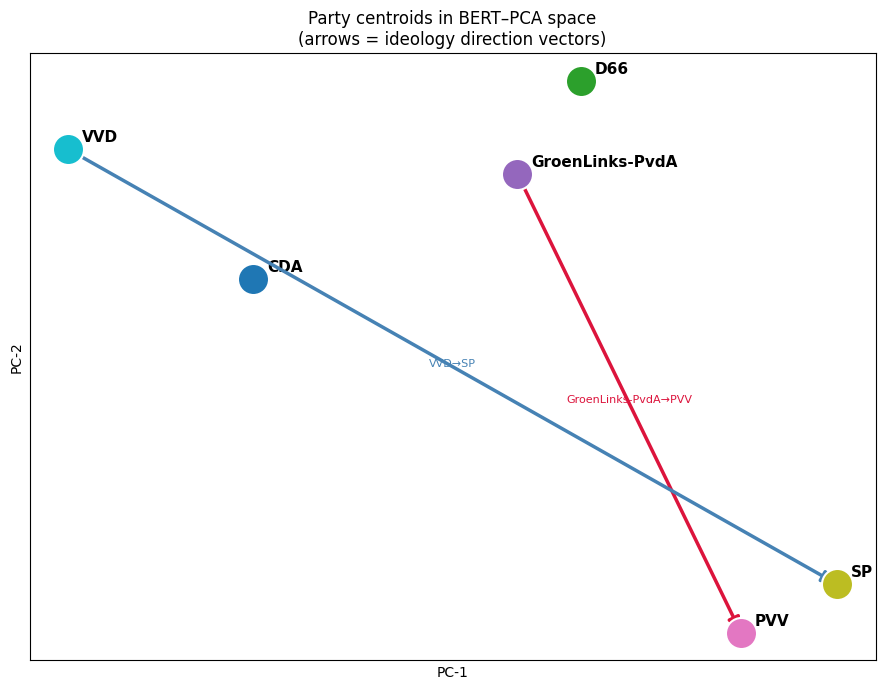

Saved: party_centroids.png


In [10]:
# Compute mean embedding per party
party_means = {}
for party, group in speeches_df.groupby("party"):
    idx = group.index.tolist()
    party_means[party] = embeddings[idx].mean(axis=0)

print("Party centroids computed for:", list(party_means.keys()))

def direction_vector(party_a, party_b):
    """Normalised direction from party_b toward party_a in BERT space."""
    diff = party_means[party_a] - party_means[party_b]
    return diff / np.linalg.norm(diff)

def project_on_axis(embs, party_a, party_b):
    """Scalar score: positive = more like party_a, negative = more like party_b."""
    return embs @ direction_vector(party_a, party_b)

# ── Party centroid map ─────────────────────────────────────────────────────────
# Project all centroids into the same PCA space used for the speech scatter
party_names = list(party_means.keys())
centroid_matrix = np.stack([party_means[p] for p in party_names])
centroids_2d = pca.transform(centroid_matrix)[:, :2]   # reuse the PCA fit from Phase 1C

fig, ax = plt.subplots(figsize=(9, 7))
for i, party in enumerate(party_names):
    c = party_color.get(party, "grey")
    ax.scatter(*centroids_2d[i], s=500, color=c, zorder=5,
               edgecolors="white", linewidths=1.5)
    ax.annotate(party, centroids_2d[i],
                textcoords="offset points", xytext=(10, 5),
                fontsize=11, fontweight="bold")

# Draw key direction arrows
arrow_axes = [
    ("PVV",            "GroenLinks-PvdA"),
    ("SP",             "VVD"),
]
arrow_colors = ["crimson", "steelblue"]
for (pa, pb), col in zip(arrow_axes, arrow_colors):
    if pa not in party_names or pb not in party_names:
        continue
    ia, ib = party_names.index(pa), party_names.index(pb)
    ax.annotate(
        "", xy=centroids_2d[ia], xytext=centroids_2d[ib],
        arrowprops=dict(arrowstyle="-|>", color=col, lw=2.5, mutation_scale=18),
    )
    mx = (centroids_2d[ia, 0] + centroids_2d[ib, 0]) / 2
    my = (centroids_2d[ia, 1] + centroids_2d[ib, 1]) / 2
    ax.text(mx, my, f"{pb}→{pa}", fontsize=8, color=col, ha="center")

ax.set_title("Party centroids in BERT–PCA space\n(arrows = ideology direction vectors)", fontsize=12)
ax.set_xlabel("PC-1"); ax.set_ylabel("PC-2")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig("party_centroids.png", dpi=150)
plt.show()
print("Saved: party_centroids.png")

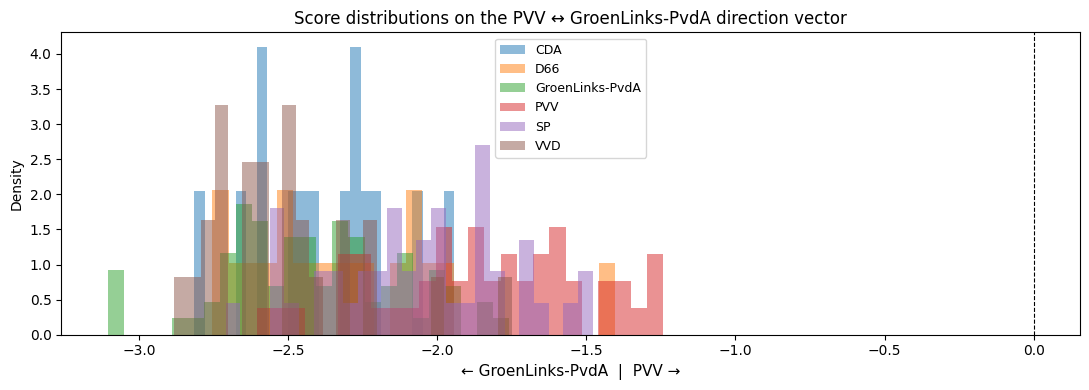

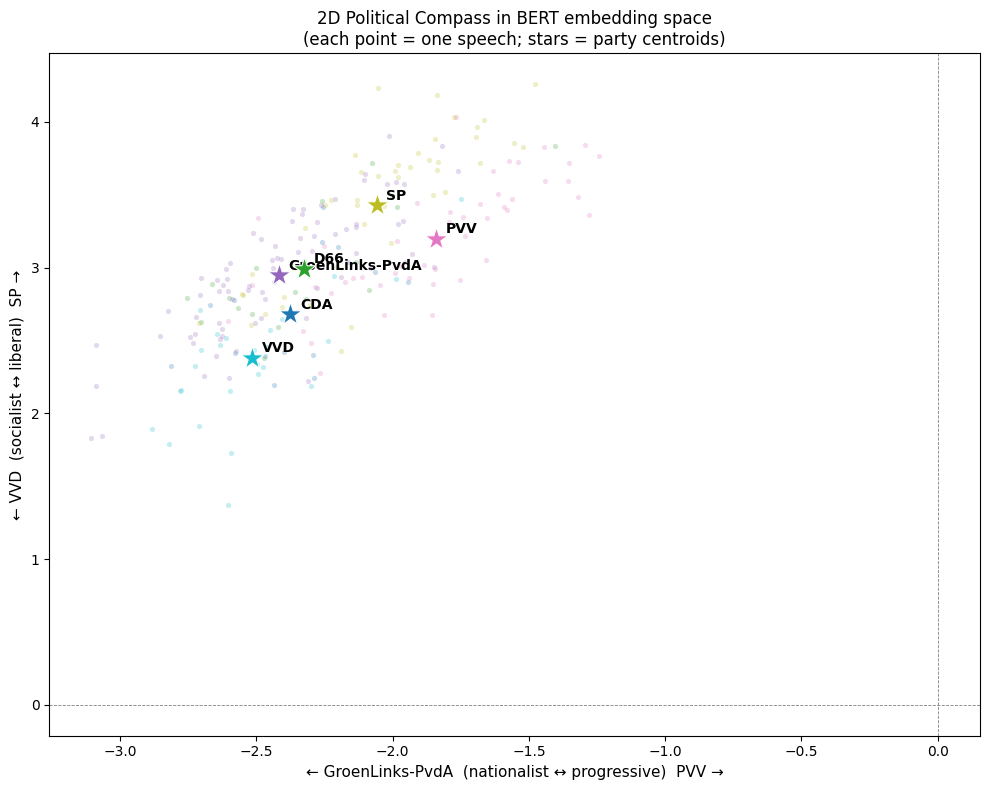

Saved: political_compass_2d.png


In [11]:
# ── 1D histogram: score distributions per party on one axis ──────────────────
AXIS_A = "PVV"
AXIS_B = "GroenLinks-PvdA"

scores = project_on_axis(embeddings, AXIS_A, AXIS_B)
speeches_df["axis_score"] = scores

fig, ax = plt.subplots(figsize=(11, 4))
for party, group in speeches_df.groupby("party"):
    ax.hist(group["axis_score"], bins=25, alpha=0.5, label=party, density=True)
ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel(f"← {AXIS_B}  |  {AXIS_A} →", fontsize=11)
ax.set_ylabel("Density")
ax.set_title(f"Score distributions on the {AXIS_A} ↔ {AXIS_B} direction vector")
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(f"{AXIS_A}_{AXIS_B}_scores.png", dpi=150); plt.show()

# ── 2D political compass: two direction axes simultaneously ───────────────────
# x-axis: populist-right ↔ progressive-left
# y-axis: economic-left  ↔ economic-right
X_A, X_B = "PVV", "GroenLinks-PvdA"
Y_A, Y_B = "SP",  "VVD"

if all(p in party_means for p in [X_A, X_B, Y_A, Y_B]):
    sx = project_on_axis(embeddings, X_A, X_B)
    sy = project_on_axis(embeddings, Y_A, Y_B)

    fig, ax = plt.subplots(figsize=(10, 8))

    for party, group in speeches_df.groupby("party"):
        idx = group.index
        c = party_color.get(party, "grey")
        ax.scatter(sx[idx], sy[idx], color=c, alpha=0.25, s=14, linewidths=0)
        cx, cy = sx[idx].mean(), sy[idx].mean()
        ax.scatter(cx, cy, color=c, s=300, marker="*", zorder=5,
                   edgecolors="white", linewidths=0.8)
        ax.annotate(party, (cx, cy), textcoords="offset points",
                    xytext=(7, 4), fontsize=10, fontweight="bold")

    ax.axhline(0, color="grey", linewidth=0.6, linestyle="--")
    ax.axvline(0, color="grey", linewidth=0.6, linestyle="--")
    ax.set_xlabel(f"← {X_B}  (nationalist ↔ progressive)  {X_A} →", fontsize=11)
    ax.set_ylabel(f"← {Y_B}  (socialist ↔ liberal)  {Y_A} →", fontsize=11)
    ax.set_title("2D Political Compass in BERT embedding space\n"
                 "(each point = one speech; stars = party centroids)", fontsize=12)
    plt.tight_layout()
    plt.savefig("political_compass_2d.png", dpi=150)
    plt.show()
    print("Saved: political_compass_2d.png")
else:
    print("Adjust X_A/X_B/Y_A/Y_B to parties present in your dataset.")

---
## Phase 2B — What Does the Direction Vector Actually Encode?

The earlier approach (projecting static token embeddings) is essentially Word2Vec — it ignores context.

A better question: **take the speeches that score most extremely on each direction, and ask what words actually differ between them.** This is grounded in the contextual BERT representations, not pre-trained priors.

The speeches at the positive extreme of `PVV→GL` are the ones BERT has decided "sound most like PVV" in its 768D space. What's in them?

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

def contextual_vocab(party_a, party_b, top_k=20, extreme_n=20):
    """
    Find discriminative vocabulary by looking at actual speech content at the
    extremes of the direction vector — not static token embeddings.
    
    These are the speeches BERT has decided sound most like party_a or party_b
    in its contextual embedding space.
    """
    scores = project_on_axis(embeddings, party_a, party_b)

    sorted_idx = np.argsort(scores)
    most_a_idx = sorted_idx[-extreme_n:]   # highest score = most like party_a
    most_b_idx = sorted_idx[:extreme_n]    # lowest score  = most like party_b

    texts_a = speeches_df.iloc[most_a_idx]["text"].tolist()
    texts_b = speeches_df.iloc[most_b_idx]["text"].tolist()

    # Show which parties those extreme speeches actually come from
    parties_a = speeches_df.iloc[most_a_idx]["party"].value_counts().to_dict()
    parties_b = speeches_df.iloc[most_b_idx]["party"].value_counts().to_dict()
    print(f"Most '{party_a}'-like speeches by party: {parties_a}")
    print(f"Most '{party_b}'-like speeches by party: {parties_b}\n")

    # TF-IDF difference: what words are distinctive in each extreme group?
    all_texts = texts_a + texts_b
    vec = TfidfVectorizer(
        max_features=8000, min_df=2,
        token_pattern=r"\b[a-zA-Zàáâãäåæçèéêëìíîïðñòóôõöøùúûüýþÿ]{4,}\b"
    )
    tfidf = vec.fit_transform(all_texts).toarray()

    mean_a = tfidf[:extreme_n].mean(axis=0)
    mean_b = tfidf[extreme_n:].mean(axis=0)
    diff = mean_a - mean_b

    words = vec.get_feature_names_out()
    top_a = np.argsort(diff)[-top_k:][::-1]
    top_b = np.argsort(diff)[:top_k]

    print(f"  {'Words → most ' + party_a:35s}  {'Words → most ' + party_b}")
    print(f"  {'─'*35}  {'─'*35}")
    for ia, ib in zip(top_a, top_b):
        print(f"  {words[ia]:25s} {diff[ia]:+.3f}    {words[ib]:25s} {diff[ib]:+.3f}")


print(f"=== {AXIS_A} ↔ {AXIS_B} — contextual vocabulary ===\n")
contextual_vocab(AXIS_A, AXIS_B)

=== PVV ↔ GroenLinks-PvdA — contextual vocabulary ===

Most 'PVV'-like speeches by party: {'PVV': 16, 'SP': 3, 'D66': 1}
Most 'GroenLinks-PvdA'-like speeches by party: {'GroenLinks-PvdA': 10, 'VVD': 7, 'CDA': 1, 'D66': 1, 'SP': 1}

  Words → most PVV                     Words → most GroenLinks-PvdA
  ───────────────────────────────────  ───────────────────────────────────
  zijn                      +0.092    hebben                    -0.084
  door                      +0.073    brief                     -0.083
  nederland                 +0.064    pvda                      -0.082
  worden                    +0.058    groenlinks                -0.082
  werd                      +0.057    steun                     -0.069
  meer                      +0.055    commissiedebat            -0.067
  jongeren                  +0.051    debat                     -0.059
  asiel                     +0.046    denk                      -0.058
  migratie                  +0.046    plenair            

In [13]:
# Try the socioeconomic axis too
if "SP" in party_means and "VVD" in party_means:
    print("\n=== SP ↔ VVD — contextual vocabulary ===\n")
    contextual_vocab("SP", "VVD")


=== SP ↔ VVD — contextual vocabulary ===

Most 'SP'-like speeches by party: {'SP': 13, 'PVV': 4, 'GroenLinks-PvdA': 2, 'D66': 1}
Most 'VVD'-like speeches by party: {'VVD': 11, 'GroenLinks-PvdA': 6, 'CDA': 2, 'PVV': 1}

  Words → most SP                      Words → most VVD
  ───────────────────────────────────  ───────────────────────────────────
  mensen                    +0.144    betreft                   -0.088
  meer                      +0.070    steun                     -0.078
  zijn                      +0.069    plenair                   -0.069
  moeten                    +0.058    commissiedebat            -0.062
  heel                      +0.058    verzoek                   -0.061
  worden                    +0.057    brief                     -0.058
  door                      +0.057    mevrouw                   -0.056
  dijk                      +0.055    morgen                    -0.053
  jimmy                     +0.055    moties                    -0.049
  jaar    

---
## Phase 3 — Score New Text

Embed any Dutch text and project it onto the ideology axes.  
The score is normalised to a z-score against the training distribution, so ±1 means one standard deviation from the centre.

In [14]:
@torch.no_grad()
def embed_single(text):
    enc = tokenizer(
        text, return_tensors="pt",
        truncation=True, max_length=512
    ).to(DEVICE)
    out = model(**enc)
    return mean_pool(out.last_hidden_state, enc.attention_mask).cpu().numpy()[0]


def score_text(text, party_a, party_b, verbose=True):
    """Score a text on the party_a ↔ party_b axis, returns z-score."""
    vec = embed_single(text)
    d = direction_vector(party_a, party_b)
    raw_score = float(vec @ d)

    # Z-score: normalise against training distribution
    train_scores = project_on_axis(embeddings, party_a, party_b)
    z = (raw_score - train_scores.mean()) / train_scores.std()
    pctile = float((train_scores < raw_score).mean() * 100)

    if verbose:
        snippet = text[:90] + ("…" if len(text) > 90 else "")
        bar_len = min(int(abs(z) * 8), 30)
        bar = "█" * bar_len
        side = f"→ {party_a}" if z > 0 else f"← {party_b}"
        print(f"  Text:  {snippet!r}")
        print(f"  Axis:  {party_a} ↔ {party_b}")
        print(f"  Score: z = {z:+.2f}  ({pctile:.0f}th percentile)  {side}  {bar}")
        print()
    return z


# Demo texts — try your own
demo_texts = [
    "Nederland is vol. We moeten de grenzen sluiten en de immigratie stoppen.",
    "We investeren in klimaatbeleid en werken samen met Europa aan een duurzame toekomst.",
    "De zorg moet toegankelijk zijn voor iedereen, niet alleen voor mensen met geld.",
    "Ondernemers moeten minder belasting betalen zodat de economie kan groeien.",
]

print(f"=== Scoring on {AXIS_A} ↔ {AXIS_B} axis ===\n")
for t in demo_texts:
    score_text(t, AXIS_A, AXIS_B)

=== Scoring on PVV ↔ GroenLinks-PvdA axis ===

  Text:  'Nederland is vol. We moeten de grenzen sluiten en de immigratie stoppen.'
  Axis:  PVV ↔ GroenLinks-PvdA
  Score: z = +2.79  (100th percentile)  → PVV  ██████████████████████

  Text:  'We investeren in klimaatbeleid en werken samen met Europa aan een duurzame toekomst.'
  Axis:  PVV ↔ GroenLinks-PvdA
  Score: z = +0.19  (59th percentile)  → PVV  █

  Text:  'De zorg moet toegankelijk zijn voor iedereen, niet alleen voor mensen met geld.'
  Axis:  PVV ↔ GroenLinks-PvdA
  Score: z = +1.55  (92th percentile)  → PVV  ████████████

  Text:  'Ondernemers moeten minder belasting betalen zodat de economie kan groeien.'
  Axis:  PVV ↔ GroenLinks-PvdA
  Score: z = +1.74  (94th percentile)  → PVV  █████████████



In [15]:
def political_compass(text, axes=None):
    """
    Score text on multiple ideological axes simultaneously.
    Prints a mini-dashboard showing where the text sits on each axis.
    """
    if axes is None:
        candidates = [
            ("PVV",  "D66"),      # populist-nationalist ↔ progressive-liberal
            ("PVV",  "GL-PvdA"),  # right-populist ↔ left-green
            ("SP",   "VVD"),      # socialist ↔ economic liberal
            ("CDA",  "D66"),      # christian-democrat ↔ social-liberal
        ]
        axes = [(a, b) for (a, b) in candidates
                if a in party_means and b in party_means]

    vec = embed_single(text)
    snippet = text[:100] + ("…" if len(text) > 100 else "")
    print(f"Text: {snippet!r}\n")

    for party_a, party_b in axes:
        d = direction_vector(party_a, party_b)
        raw = float(vec @ d)
        train = project_on_axis(embeddings, party_a, party_b)
        z = (raw - train.mean()) / train.std()
        side_label = party_a if z > 0 else party_b
        bar_len = min(int(abs(z) * 6), 24)
        bar = "█" * bar_len
        print(f"  {party_a:10s} ↔ {party_b:10s}  z={z:+.2f}  → {side_label:12s}  {bar}")


print("=== Political Compass ===\n")
political_compass(
    "Wij staan voor een open samenleving, een sterk Europa en gelijke kansen voor iedereen."
)
print()
political_compass(
    "De elite in Den Haag luistert niet naar gewone Nederlanders. Genoeg is genoeg."
)

=== Political Compass ===

Text: 'Wij staan voor een open samenleving, een sterk Europa en gelijke kansen voor iedereen.'

  PVV        ↔ D66         z=+0.58  → PVV           ███
  SP         ↔ VVD         z=+0.75  → SP            ████
  CDA        ↔ D66         z=+0.18  → CDA           █

Text: 'De elite in Den Haag luistert niet naar gewone Nederlanders. Genoeg is genoeg.'

  PVV        ↔ D66         z=+1.99  → PVV           ███████████
  SP         ↔ VVD         z=+0.41  → SP            ██
  CDA        ↔ D66         z=+0.84  → CDA           █████


---
## What's next?

**Validate the geometry more rigorously**
- Compute cosine similarities between party means — does the political distance match your intuition?
- Try a held-out party (e.g. ChristenUnie) and see where it projects without being in the training data.

**Better direction vectors**
- Instead of raw mean-difference, use the **first PCA component of the within-class covariance** — this is what Zou et al. (2023) call the "Representation Engineering" approach and it's more robust.
- Try extracting activations at intermediate layers (e.g. layer 8 of 12) — political information might be more concentrated there.

**Historical drift**
- The OData API goes back years. Fetch speeches from 2015–2017 vs. 2022–2024 separately.
- Compute direction vectors for each period — has VVD drifted towards PVV since the coalition negotiations?

**Richer visualisation**
- Plot a 2D compass: project onto two orthogonal axes simultaneously (e.g. PVV↔GL on x, SP↔VVD on y).
- Colour the UMAP plot by projection score rather than party label — shows within-party variation.

**Calibration check**
- Score party *manifestos* (verkiezingsprogramma's), which are available as PDFs, and see if their positions match Kieskompas scores.